In [1]:
import pickle
import torch
import pandas as pd
import torch
from GloVe import GloVeModel
from tools import SpacyTokenizer, Dictionary

In [2]:
FILE_PATH = '../all_datasets_transformers.csv'
MODEL_PATH = './glove.pt'
DOC_PATH = './corpus.pickle'
COMATRIX_PATH = './comat.pickle'
TXT_EMBED_PATH = './glove_custom_200d.txt'
LANG = 'en_core_web_sm'
EMBEDDING_SIZE = 200
CONTEXT_SIZE = 5
NUM_EPOCH = 50
BATCH_SIZE = 512
LEARNING_RATE = 0.005

In [3]:
def read_data_csv(file_path, column='text', limit=10000):
    df = pd.read_csv(file_path)
    df = df[column].dropna().astype(str)
    if limit:
        df = df.head(limit)
    return " ".join(df.tolist())

In [4]:
def preprocess(file_path):
    text = read_data_csv(file_path)
    print("CSV successfully read")

    tokenizer = SpacyTokenizer(LANG)
    dictionary = Dictionary()

    doc = tokenizer.tokenize(text)
    print("Tokenized text from data.")

    with open(DOC_PATH, mode='wb') as fp:
        pickle.dump(doc, fp)
    print("Document successfully saved.")

    dictionary.update(doc)
    print("Dictionary successfully updated.")

    corpus = dictionary.corpus(doc)
    vocab_size = dictionary.vocab_size

    return corpus, vocab_size, dictionary

In [5]:
def save_embeddings_as_txt(model, dictionary, filename=TXT_EMBED_PATH):
    focal = model._focal_embeddings.weight.data.cpu().numpy()
    context = model._context_embeddings.weight.data.cpu().numpy()

    combined = (focal + context) / 2  # average the two embeddings

    with open(filename, 'w', encoding='utf-8') as f:
        for word, idx in dictionary.word2idx.items():
            vector = combined[idx]
            vector_str = " ".join(map(str, vector))
            f.write(f"{word} {vector_str}\n")

    print(f"Saved embeddings in GloVe format to: {filename}")

In [13]:
def train_glove_model():
    corpus, vocab_size, dictionary = preprocess(FILE_PATH)

    device = torch.device('cuda:2' if torch.cuda.is_available() else 'cpu')

    model = GloVeModel(EMBEDDING_SIZE, CONTEXT_SIZE, vocab_size)
    model.to(device)
    print("Running on:", device)

    model.fit(corpus)
    coocurance_matrix = model.get_coocurrance_matrix()

    with open(COMATRIX_PATH, mode='wb') as fp:
        pickle.dump(coocurance_matrix, fp)

    history = model.train_glove(NUM_EPOCH, device)  # capturezi history

    save_embeddings_as_txt(model, dictionary, filename=TXT_EMBED_PATH)

    torch.save(model.state_dict(), MODEL_PATH)
    print(f"Model saved to {MODEL_PATH}")
    
    return history  

In [14]:
import importlib
import GloVe
importlib.reload(GloVe)
from GloVe import GloVeModel
import torch

In [15]:
import importlib
import tools
importlib.reload(tools)
from tools import SpacyTokenizer, Dictionary

In [16]:
history=train_glove_model()

CSV successfully read


/home/bianca.guceanu/.local/lib/python3.10/site-packages/spacy/pipeline/lemmatizer.py:188: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)


Tokenized text from data.
Document successfully saved.
Dictionary successfully updated.
Running on: cuda:2
Start training...

-------------------------------------------------------------
 EPOCH  |   TRAIN LOSS   |    VAL LOSS    | TIME (s) 
-------------------------------------------------------------
   1    |    0.283410    |    0.160708    |   7.13   
   2    |    0.210999    |    0.101364    |   7.12   
   3    |    0.199953    |    0.072515    |   7.15   
   4    |    0.127053    |    0.059615    |   7.23   
   5    |    0.123474    |    0.049502    |   7.11   
   6    |    0.105167    |    0.042963    |   7.23   
   7    |    0.087239    |    0.037190    |   7.11   
   8    |    0.076475    |    0.034073    |   7.06   
   9    |    0.065726    |    0.030897    |   7.15   
  10    |    0.056935    |    0.028707    |   7.12   
  11    |    0.049624    |    0.027099    |   7.39   
  12    |    0.043886    |    0.026077    |   7.06   
  13    |    0.039191    |    0.024966    |   7.

In [17]:
def plot_graphs(history, metric):
    import matplotlib.pyplot as plt
    import numpy as np

    epochs = np.arange(1, len(history[metric]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history[metric], label=metric.capitalize())
    plt.plot(epochs, history['val_' + metric], label='Validation ' + metric.capitalize())
    plt.title(f'{metric.capitalize()} per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel(metric.capitalize())
    plt.xticks(epochs)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


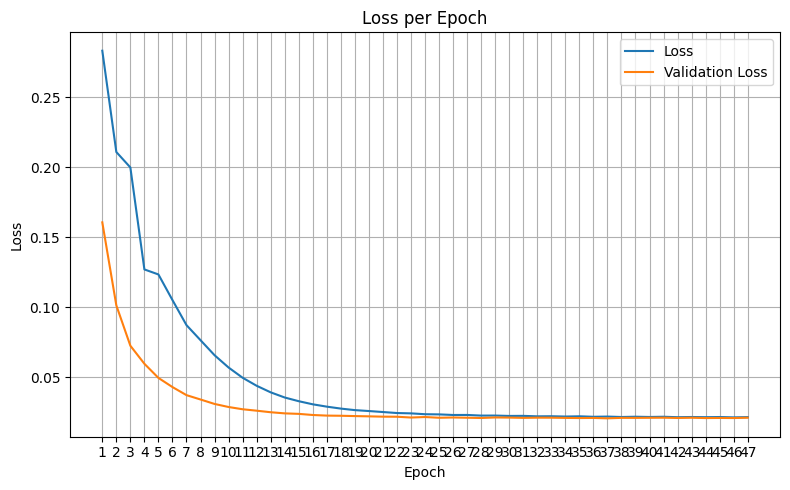

In [18]:
plot_graphs(history, "loss")